In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/Restaurant111.csv", encoding="latin1")


In [3]:
df.head()

,web_scraper_order,web_scraper_start_url,name,cuisine,price,dining_rating,link,dining_votes,delivery_rating,delivery_votes,location
0,1774775120-1,https://www.zomato.com/kochi,KO KO RO Cafe,"Desserts, Juices, Indo-Chinese, French, Chines...",?700 for two,New,https://www.zomato.com/kochi/ko-ko-ro-cafe-ern...,0,-,0,"40/12, Thrikkakara Circle, Thammanam, Pullepad..."
1,1774775124-2,https://www.zomato.com/kochi,KFC,"Burger, Fast Food, Rolls",?450 for two,-,https://www.zomato.com/kochi/kfc-ernakulam-cit...,1,-,1,"Ground Floor, Door 355/B & First Floor, Door 3..."
2,1774775132-3,https://www.zomato.com/kochi,Tabasco,"Arabian, Shawarma, Burger, Salad","?1,000 for two",-,https://www.zomato.com/kochi/tabasco-ernakulam...,1,-,1,"Door 30/461/K, Que West Properties, Ernakulam ..."
3,1774775135-4,https://www.zomato.com/kochi,Hotel Salwa,"South Indian, Kerala",?400 for two,3.4,https://www.zomato.com/kochi/hotel-salwa-ernak...,26,3.4,26,"XI/1394, OPP Bus Stop, Thoppumpady Jn, Ernakul..."
4,1774775138-5,https://www.zomato.com/kochi,Badai Bungalow,"Sandwich, Shawarma, Street Food, Tea",?250 for two,-,https://www.zomato.com/kochi/badai-bungalow-er...,0,-,0,"Vadakkedath House, Aluva Circle, Ernakulam Cit..."


In [4]:
df.shape

(3820, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3820 entries, 0 to 3819
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      3820 non-null   object
 1   web_scraper_start_url  3820 non-null   object
 2   name                   3820 non-null   object
 3   cuisine                3820 non-null   object
 4   price                  3820 non-null   object
 5   dining_rating          3820 non-null   object
 6   link                   3820 non-null   object
 7   dining_votes           3820 non-null   object
 8   delivery_rating        3820 non-null   object
 9   delivery_votes         3820 non-null   object
 10  location               3820 non-null   object
dtypes: object(11)
memory usage: 328.4+ KB


In [6]:
df['dining_rating'].value_counts()

,count
dining_rating,
-,629
4.3,368
4.2,306
4.5,301
4.4,290
4.1,290
4,283
3.9,229
3.8,152


In [7]:
df['dining_rating'] = df['dining_rating'].replace(['-', 'New'], None)

In [8]:
df['dining_rating'] = pd.to_numeric(df['dining_rating'], errors='coerce')

In [9]:
df['price'].value_counts()

,count
price,
?100 for one,357
?200 for one,300
?150 for one,285
?300 for two,276
"?1,000 for two",194
...,...
"?4,100 for two",1
"?5,800 for two",1
"?10,000 for two",1


In [10]:
# convert to string
df['price'] = df['price'].astype(str)

# identify 'for two'
df['is_two'] = df['price'].str.contains('for two', na=False)

# remove text
df['price'] = df['price'].str.replace('for one', '', regex=False)
df['price'] = df['price'].str.replace('for two', '', regex=False)

# remove symbols
df['price'] = df['price'].str.replace('₹', '', regex=False)
df['price'] = df['price'].str.replace('?', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)

# strip spaces
df['price'] = df['price'].str.strip()

# convert to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# divide only 'for two' rows
df.loc[df['is_two'], 'price'] = df.loc[df['is_two'], 'price'] / 2

# drop helper column
df.drop('is_two', axis=1, inplace=True)

In [11]:
df['price'].value_counts()

,count
price,
150.0,561
200.0,469
100.0,453
250.0,218
500.0,198
...,...
2050.0,1
2900.0,1
5000.0,1


In [12]:
df['location'].value_counts()

,count
location,
"1270 C, Ground Floor, Kolloth Arcade, Eranhipalam, Rarichan Road, Bilathikkulam, Kozhikode",9
"16/112, Near Victoria College, Vidyut Nagar, Palakkad",8
"ITC Grand Chola, 63, Mount Road, Guindy, Chennai",4
"Mannuthi Junction, Mannuthy, Thrissur",4
"61/11600, 1st Floor, Calicut Mall, Near Stadium Junction, Puthiyara Road, Palayam, Kozhikode",3
...,...
"Aiswarya Ramanathapuram, Manali Road, Vidyut Nagar, Palakkad",1
"23/596-5, 6, Kalliyat Building, Stadium ByePass Road, Near Noorjehan, Sulthan, Kalmandapam, Palakkad",1
"21/636, Head Post Office, Kalmandapam, Palakkad",1


In [13]:
df['location'] = df['location'].str.split(',').str[-1]
df['location'] = df['location'].str.strip()

In [14]:
df['location'].value_counts()

,count
location,
Thrissur,501
Mumbai,500
Trivandrum,499
Chennai,488
Bangalore,482
Kozhikode,305
Kottayam,202
Kochi,200
Palakkad,162


In [15]:
df['location'] = df['location'].str.lower().str.strip()

In [16]:
df['location'] = df['location'].str.replace('.', '', regex=False)

In [17]:
df = df[~df['location'].isin(['', '#name?'])]     #invalid

In [18]:
df['location'] = df['location'].str.title()

In [19]:
df['location'].value_counts().head(15)

,count
location,
Thrissur,501
Mumbai,500
Trivandrum,499
Chennai,488
Bangalore,482
Kozhikode,305
Kottayam,202
Kochi,200
Palakkad,162


In [20]:
df['delivery_rating'].value_counts()

,count
delivery_rating,
-,1504
4.5,289
4.3,274
4.4,262
4.2,214
4.1,187
3.9,165
4.6,135
4,115


In [21]:
# replace invalid values
df['delivery_rating'] = df['delivery_rating'].replace(['-', 'New'], None)

# convert to numeric
df['delivery_rating'] = pd.to_numeric(df['delivery_rating'], errors='coerce')

In [22]:
# convert to string
df['delivery_votes'] = df['delivery_votes'].astype(str)

# remove commas
df['delivery_votes'] = df['delivery_votes'].str.replace(',', '', regex=False)

# convert to numeric
df['delivery_votes'] = pd.to_numeric(df['delivery_votes'], errors='coerce')

In [23]:
df['dining_votes'] = df['dining_votes'].astype(str).str.replace(',', '', regex=False)
df['dining_votes'] = pd.to_numeric(df['dining_votes'], errors='coerce')


In [24]:
df.isnull().sum()

,0
web_scraper_order,0
web_scraper_start_url,0
name,0
cuisine,0
price,8
dining_rating,712
link,0
dining_votes,52
delivery_rating,1529
delivery_votes,52


In [25]:
df['dining_votes'] = df['dining_votes'].fillna(0)
df['delivery_rating'] = df['delivery_rating'].fillna(0)
df['delivery_votes'] = df['delivery_votes'].fillna(0)


df = df.dropna(subset=['dining_rating', 'price'])


print(df.isnull().sum())

web_scraper_order        0
web_scraper_start_url    0
name                     0
cuisine                  0
price                    0
dining_rating            0
link                     0
dining_votes             0
delivery_rating          0
delivery_votes           0
location                 0
dtype: int64


In [26]:
df['success'] = df['dining_rating'].apply(lambda x: 1 if x >= 4 else 0)

In [27]:
df['success'].value_counts()

,count
success,
1,2080
0,1019


In [28]:
df['has_delivery'] = df['delivery_rating'].apply(lambda x: 1 if x > 0 else 0)

In [29]:
df['has_delivery'].value_counts()

,count
has_delivery,
1,2265
0,834


In [30]:
df['price_category'] = pd.cut(df['price'],
                               bins=[0, 300, 600, 1000, 2000],
                               labels=['Low', 'Medium', 'High', 'Luxury'])

df['price_category'].value_counts()

,count
price_category,
Low,1578
High,567
Medium,536
Luxury,379


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='dining_rating', ylabel='Count'>

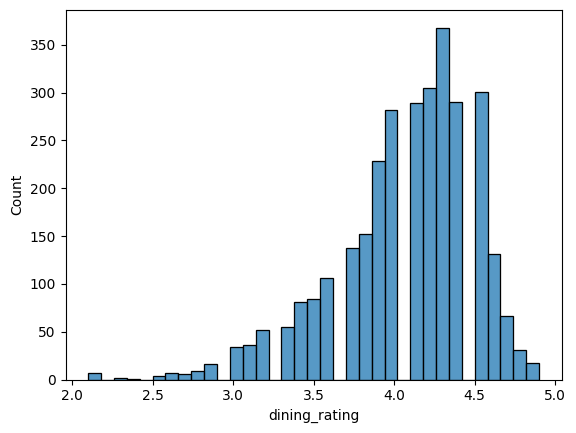

In [32]:
sns.histplot(df['dining_rating'])

<Axes: xlabel='price', ylabel='Count'>

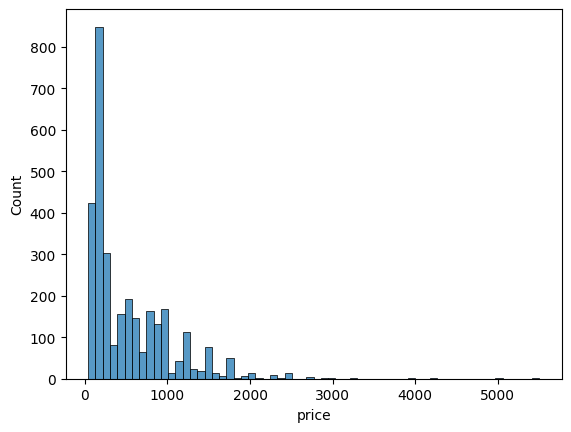

In [33]:
sns.histplot(df['price'])

<Axes: xlabel='dining_votes', ylabel='Count'>

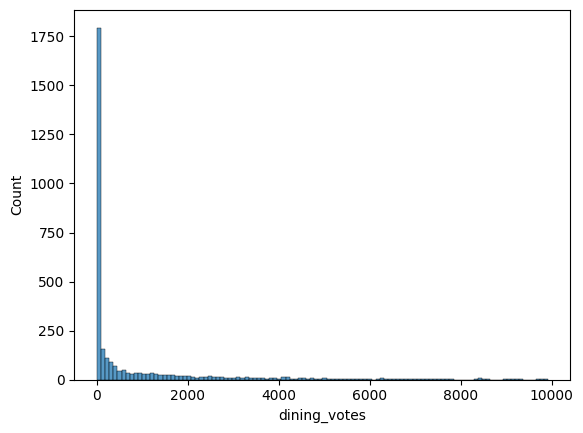

In [34]:
sns.histplot(df['dining_votes'])

<Axes: xlabel='delivery_rating', ylabel='Count'>

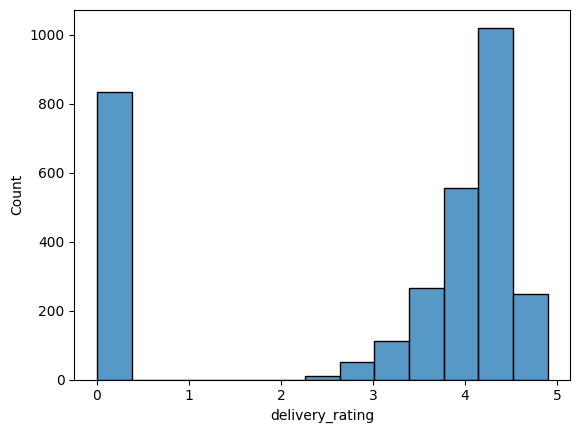

In [35]:
sns.histplot(df['delivery_rating'])

<Axes: xlabel='delivery_votes', ylabel='Count'>

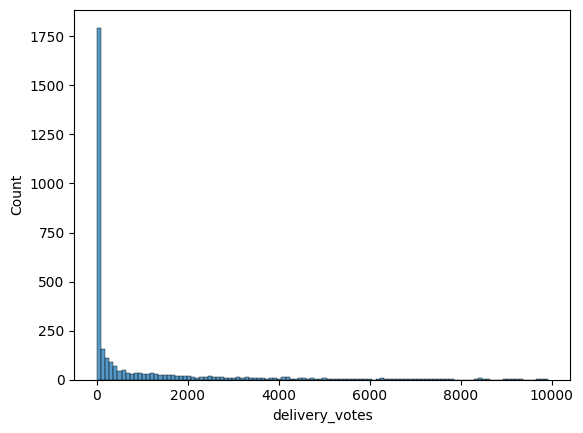

In [36]:
sns.histplot(df['delivery_votes'])

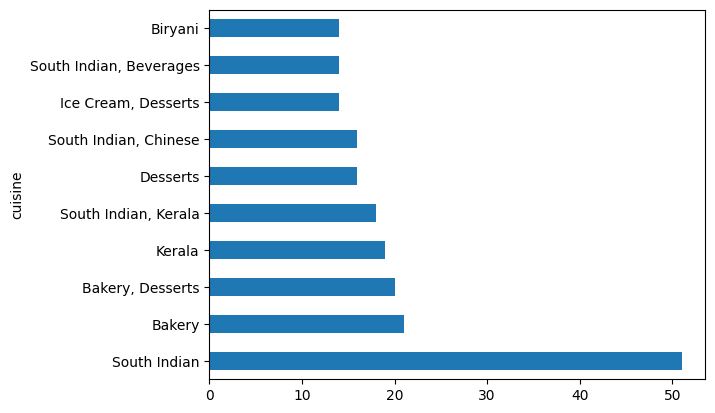

In [37]:
top_cuisines = df['cuisine'].value_counts().head(10)
top_cuisines.plot(kind='barh')
plt.show()

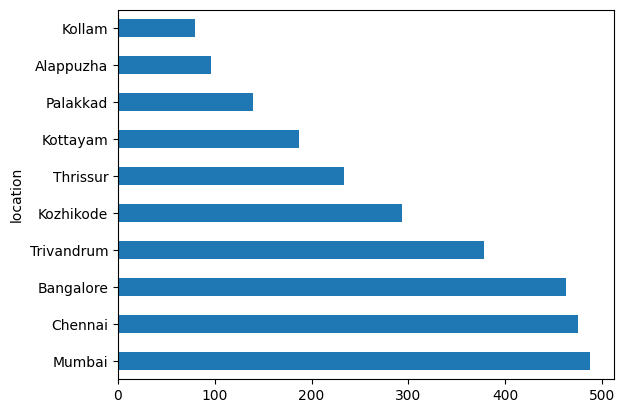

In [38]:
top_location = df['location'].value_counts().head(10)
top_location.plot(kind='barh')
plt.show()

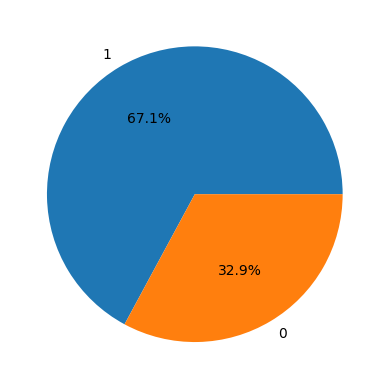

In [39]:
x = df['success'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

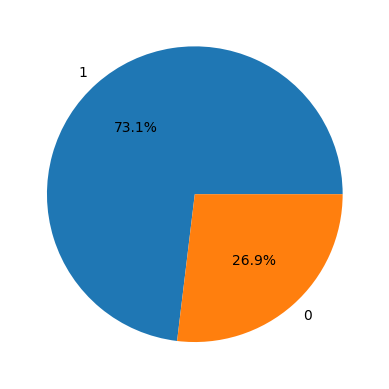

In [40]:
x = df['has_delivery'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

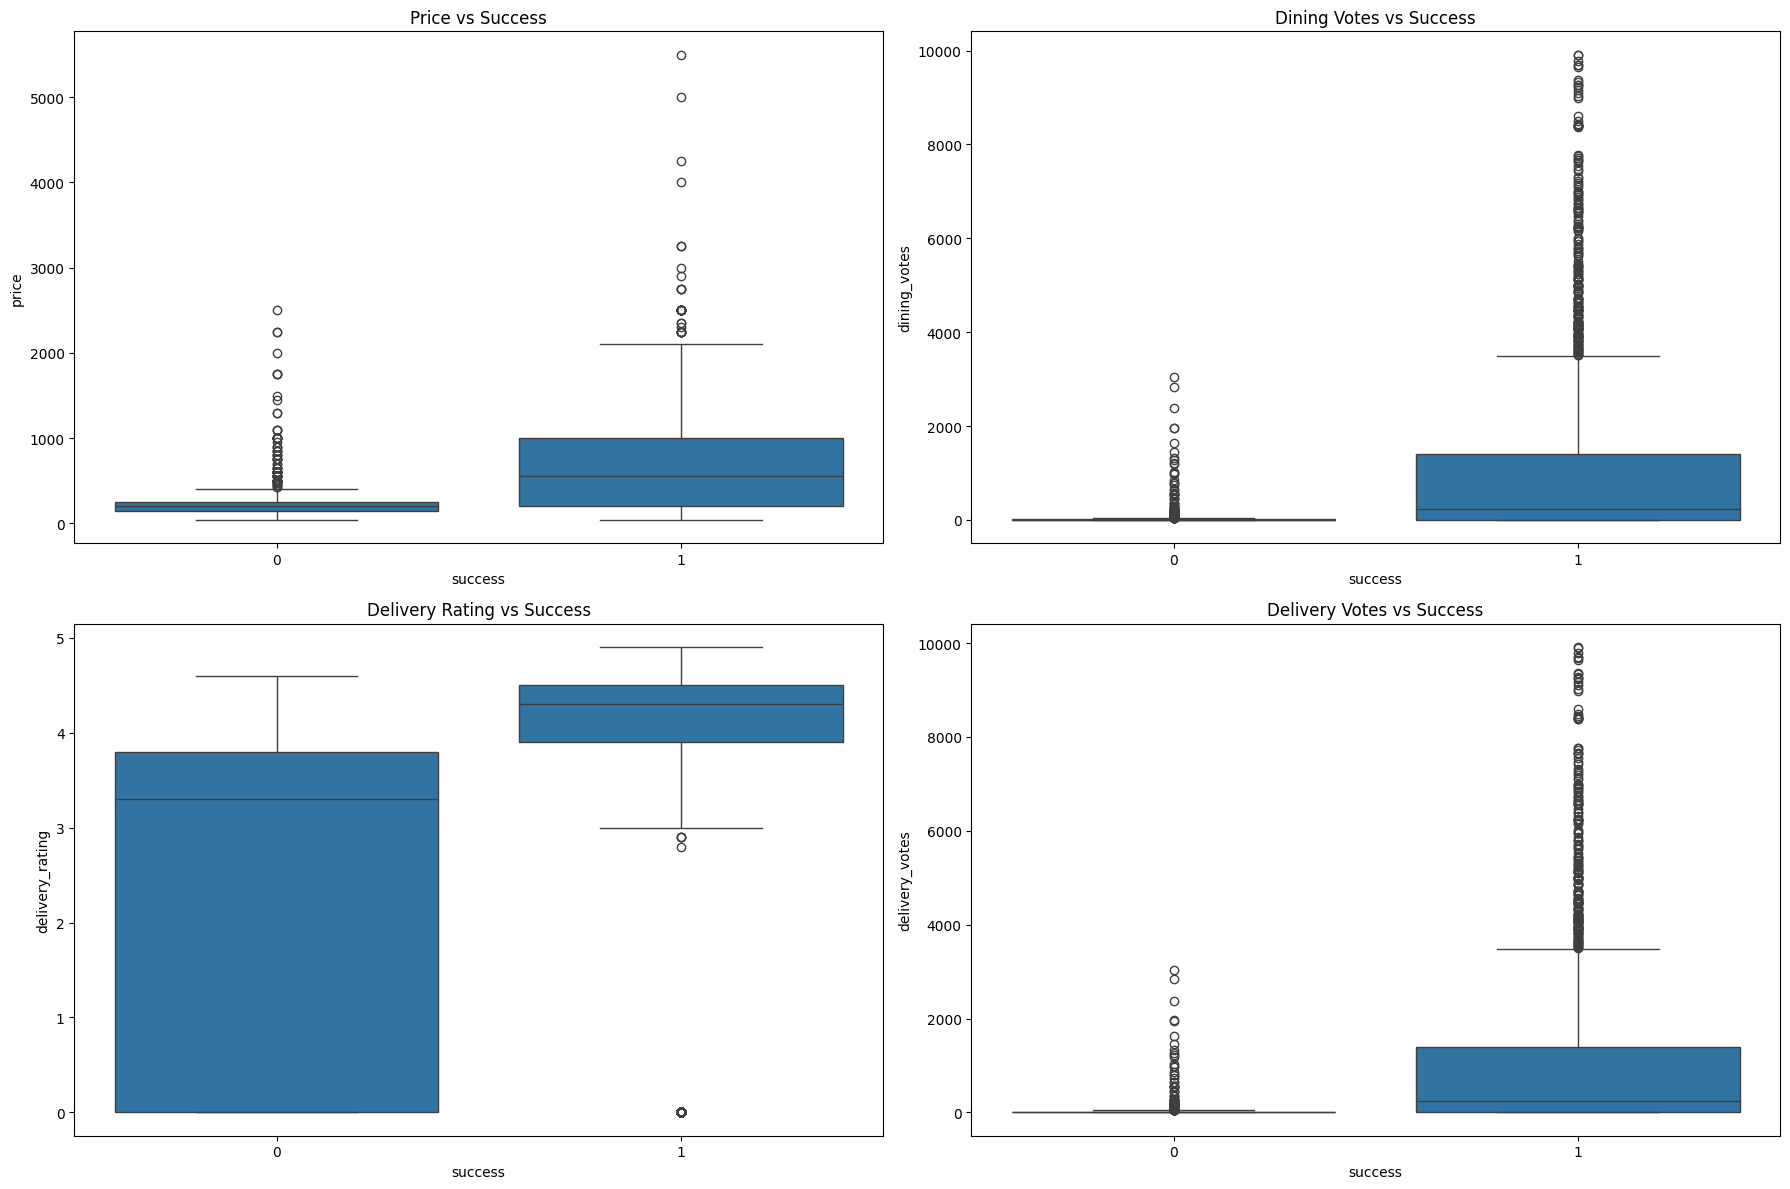

In [41]:
plt.figure(figsize=(18, 12))

# Price vs Success
plt.subplot(2, 2, 1)
sns.boxplot(x='success', y='price', data=df)
plt.title('Price vs Success')

# Dining Votes vs Success
plt.subplot(2, 2, 2)
sns.boxplot(x='success', y='dining_votes', data=df)
plt.title('Dining Votes vs Success')

# Delivery Rating vs Success
plt.subplot(2, 2, 3)
sns.boxplot(x='success', y='delivery_rating', data=df)
plt.title('Delivery Rating vs Success')

# Delivery Votes vs Success
plt.subplot(2, 2, 4)
sns.boxplot(x='success', y='delivery_votes', data=df)
plt.title('Delivery Votes vs Success')

plt.tight_layout()
plt.show()

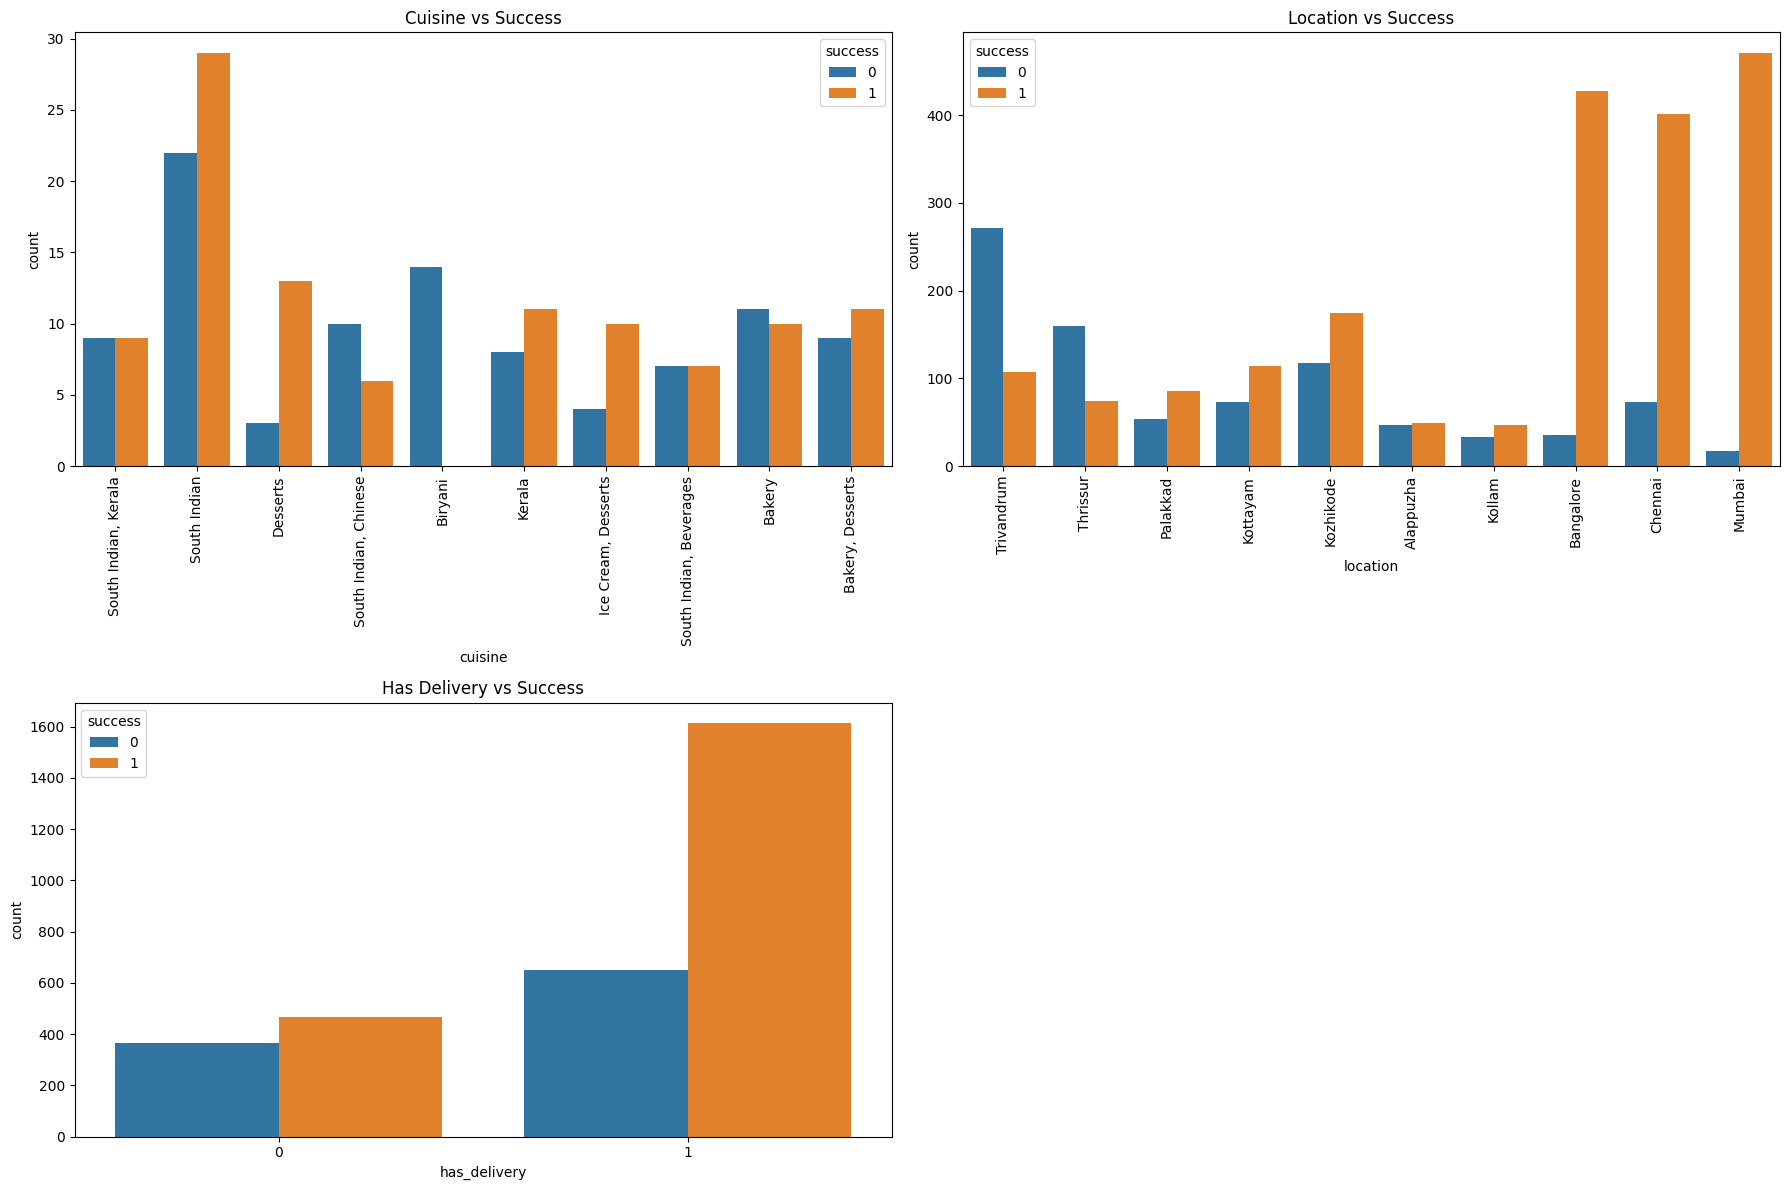

In [42]:
plt.figure(figsize=(18, 12))

# Cuisine vs Success
plt.subplot(2, 2, 1)
top_cuisines = df['cuisine'].value_counts().head(10).index
sns.countplot(x='cuisine', hue='success', data=df[df['cuisine'].isin(top_cuisines)])
plt.xticks(rotation=90)
plt.title('Cuisine vs Success')

# Location vs Success
plt.subplot(2, 2, 2)
top_locations = df['location'].value_counts().head(10).index
sns.countplot(x='location', hue='success', data=df[df['location'].isin(top_locations)])
plt.xticks(rotation=90)
plt.title('Location vs Success')

# Has Delivery vs Success
plt.subplot(2, 2, 3)
sns.countplot(x='has_delivery', hue='success', data=df)
plt.title('Has Delivery vs Success')

plt.tight_layout()
plt.show()

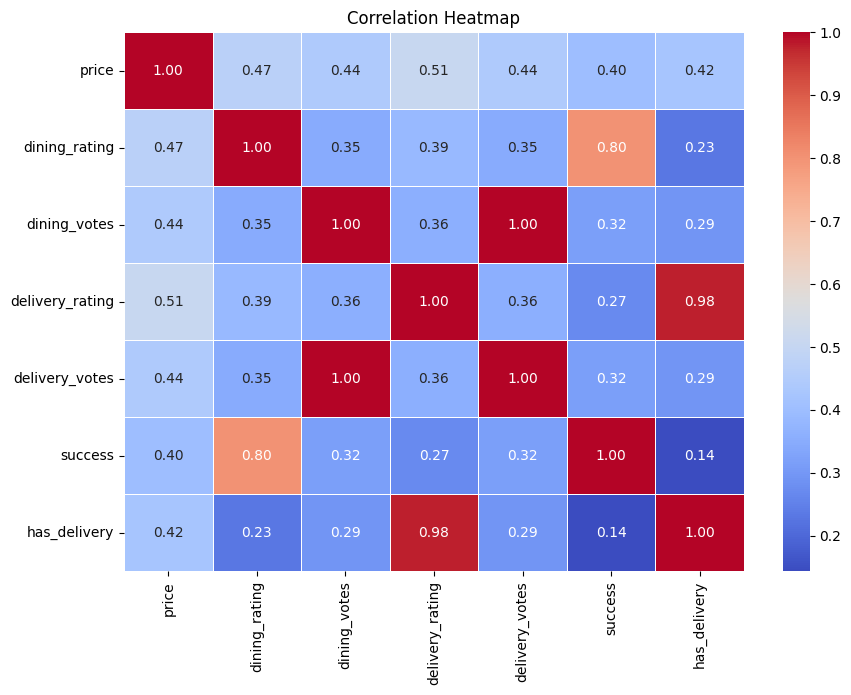

In [43]:
plt.figure(figsize=(10,7))
numeric_cols = ['price', 'dining_rating', 'dining_votes', 'delivery_rating', 'delivery_votes', 'success', 'has_delivery']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [44]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# 1. Cuisines clean
df['cuisine_split'] = df['cuisine'].apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else str(x).split(', ')
)

# 2. All cuisines collect
top_cuisines = df['cuisine_split'].explode().str.strip().value_counts().index.tolist()
print('Total Cuisines:', len(top_cuisines))

# 3. Filter
df['cuisine_filtered'] = df['cuisine_split'].apply(
    lambda x: [i.strip() for i in x if i.strip() in top_cuisines]
)

# 4. Encode
mlb = MultiLabelBinarizer(classes=top_cuisines)
encoded = mlb.fit_transform(df['cuisine_filtered'])

# 5. DataFrame
encoded_df = pd.DataFrame(encoded, columns=top_cuisines, index=df.index)

# Drop redundant columns
df = df.drop(columns=['cuisine', 'cuisine_split', 'cuisine_filtered'], errors='ignore')
df = pd.concat([df, encoded_df], axis=1)

print("Final Shape:", df.shape)

Total Cuisines: 117
Final Shape: (3099, 130)


In [45]:
location_rating = df.groupby('location')['dining_rating'].median()

def assign_tier(rating):
    if rating >= 4.3:
        return 1
    elif rating >= 4.0:
        return 2
    else:
        return 3

df['location_tier'] = df['location'].map(location_rating).apply(assign_tier)

In [46]:
df['location_tier'].value_counts()

,count
location_tier,
1,1426
2,971
3,702


In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['price_category'] = le.fit_transform(df['price_category'])
print(df['price_category'].value_counts())

price_category
1    1578
0     567
3     536
2     379
4      39
Name: count, dtype: int64


In [48]:
df.columns

Index(['web_scraper_order', 'web_scraper_start_url', 'name', 'price',
       'dining_rating', 'link', 'dining_votes', 'delivery_rating',
       'delivery_votes', 'location',
       ...
       'Russian', '', 'Snacks', 'South American', 'British', 'Kashmiri',
       'Peruvian', 'Poké', 'Himachali', 'location_tier'],
      dtype='object', length=131)